# 1. Import Libraries 

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

from sklearn.utils.class_weight import compute_sample_weight

In [42]:
!pip install xlrd

# 2. Load the XLS file

In [44]:
df = pd.read_excel(
    "default of credit card clients.xls",
    header=1,
    engine="xlrd"
)

In [45]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


# 3. Initial inspection

In [47]:
print("Shape:", df.shape)
df.info()
df.describe().T

Shape: (30000, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


# 4. Cleaning data 

In [49]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

In [50]:
df.shape

(30000, 25)

In [51]:
target_col = "default payment next month"

# Drop ID column 
df = df.drop(columns=["ID"])

# Check missing values
print("Missing values:\n", df.isna().sum().sort_values(ascending=False))

# Target distribution
print(df[target_col].value_counts())
print("Default rate:", df[target_col].mean())


Missing values:
 LIMIT_BAL                     0
SEX                           0
PAY_AMT6                      0
PAY_AMT5                      0
PAY_AMT4                      0
PAY_AMT3                      0
PAY_AMT2                      0
PAY_AMT1                      0
BILL_AMT6                     0
BILL_AMT5                     0
BILL_AMT4                     0
BILL_AMT3                     0
BILL_AMT2                     0
BILL_AMT1                     0
PAY_6                         0
PAY_5                         0
PAY_4                         0
PAY_3                         0
PAY_2                         0
PAY_0                         0
AGE                           0
MARRIAGE                      0
EDUCATION                     0
default payment next month    0
dtype: int64
default payment next month
0    23364
1     6636
Name: count, dtype: int64
Default rate: 0.2212


# 5. Train test split

In [53]:
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 6. Preprocessing 

In [55]:
categorical_features = ["SEX", "EDUCATION", "MARRIAGE"]
numeric_features = [c for c in X.columns if c not in categorical_features]


#### - Logistic Regression preprocessing

In [57]:
preprocess_lr = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)


#### - Tree model preprocessing

In [59]:
preprocess_tree = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# 7. Logistic Regression

Logistic Regression ROC-AUC: 0.7105606434759414
              precision    recall  f1-score   support

           0     0.8687    0.6912    0.7699      4673
           1     0.3677    0.6323    0.4649      1327

    accuracy                         0.6782      6000
   macro avg     0.6182    0.6617    0.6174      6000
weighted avg     0.7579    0.6782    0.7024      6000



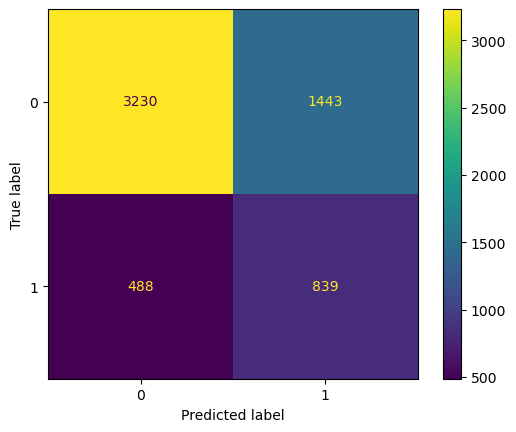

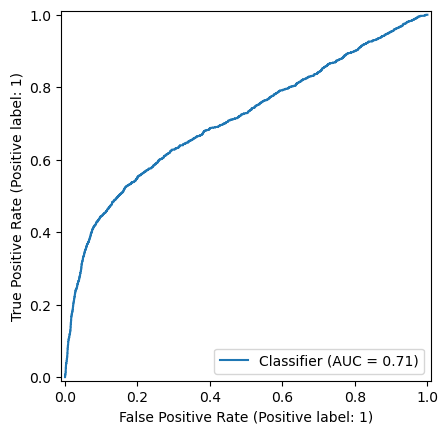

In [61]:
log_reg = Pipeline(steps=[
    ("preprocess", preprocess_lr),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

print("Logistic Regression ROC-AUC:",
      roc_auc_score(y_test, y_proba_lr))

print(classification_report(y_test, y_pred_lr, digits=4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.show()
RocCurveDisplay.from_predictions(y_test, y_proba_lr)
plt.show()

# 8. Gradient Boosting

Tree Model ROC-AUC: 0.7790644551562141
              precision    recall  f1-score   support

           0     0.8808    0.8108    0.8443      4673
           1     0.4794    0.6134    0.5382      1327

    accuracy                         0.7672      6000
   macro avg     0.6801    0.7121    0.6913      6000
weighted avg     0.7920    0.7672    0.7766      6000



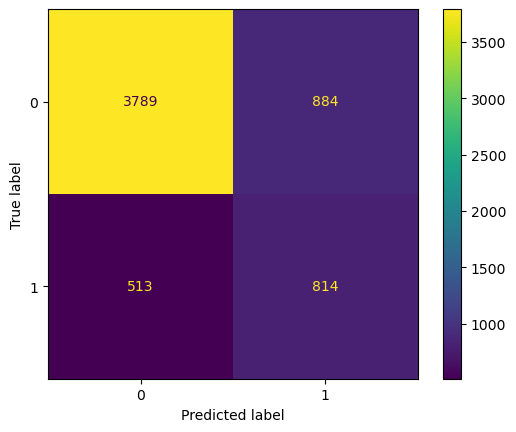

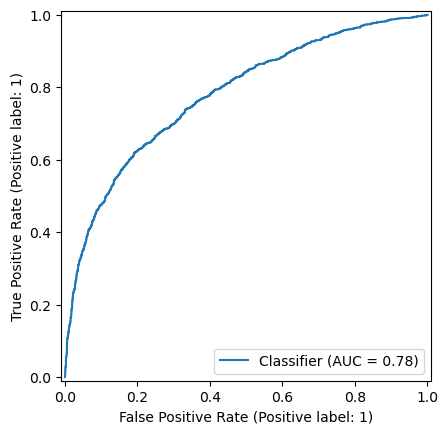

In [63]:
tree_model = Pipeline(steps=[
    ("preprocess", preprocess_tree),
    ("model", HistGradientBoostingClassifier(
        max_depth=6,
        learning_rate=0.08,
        max_iter=250,
        random_state=42
    ))
])

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

tree_model.fit(
    X_train,
    y_train,
    model__sample_weight=sample_weights
)

y_pred_tree = tree_model.predict(X_test)
y_proba_tree = tree_model.predict_proba(X_test)[:, 1]

print("Tree Model ROC-AUC:",
      roc_auc_score(y_test, y_proba_tree))

print(classification_report(y_test, y_pred_tree, digits=4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree)
plt.show()

RocCurveDisplay.from_predictions(y_test, y_proba_tree)
plt.show()


# 9. Comparison

In [65]:
def extract_metrics(y_true, y_pred, y_prob):
    rep = classification_report(y_true, y_pred, output_dict=True)
    return {
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "Precision (Default=1)": rep["1"]["precision"],
        "Recall (Default=1)": rep["1"]["recall"],
        "F1-score (Default=1)": rep["1"]["f1-score"],
    }

results = pd.DataFrame({
    "Logistic Regression": extract_metrics(y_test, y_pred_lr, y_proba_lr),
    "Gradient Boosting": extract_metrics(y_test, y_pred_tree, y_proba_tree)
}).T

results

,ROC_AUC,Precision (Default=1),Recall (Default=1),F1-score (Default=1)
Logistic Regression,0.710561,0.367660,0.632253,0.464949
Gradient Boosting,0.779064,0.479388,0.613414,0.538182


# 10. SHAP

 99%|===================| 5922/6000 [00:30<00:00]        

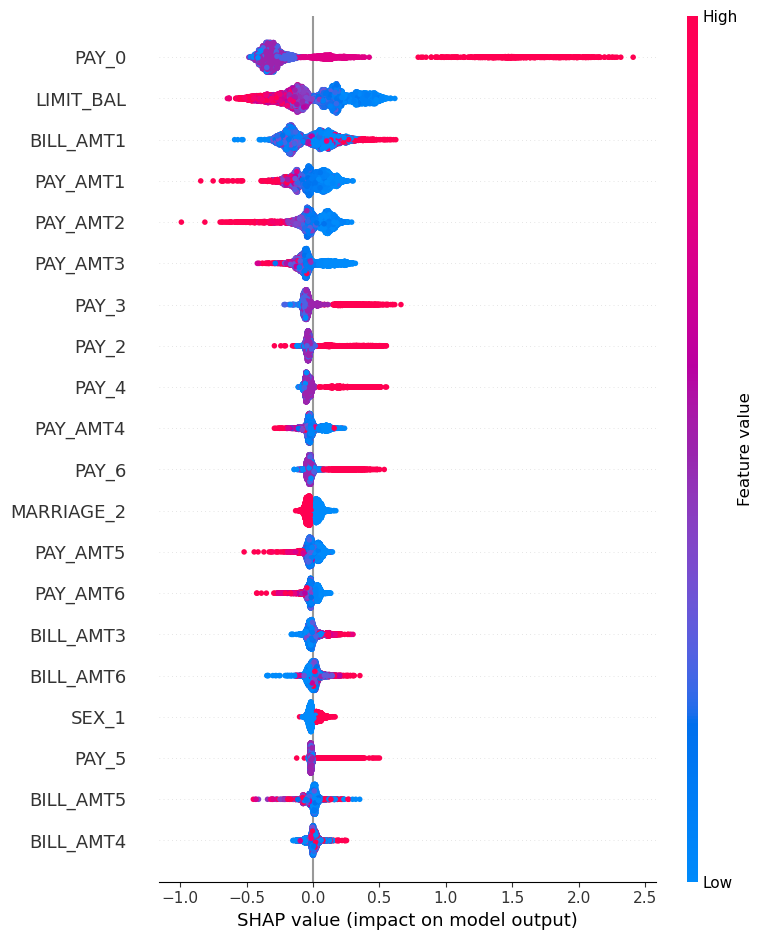

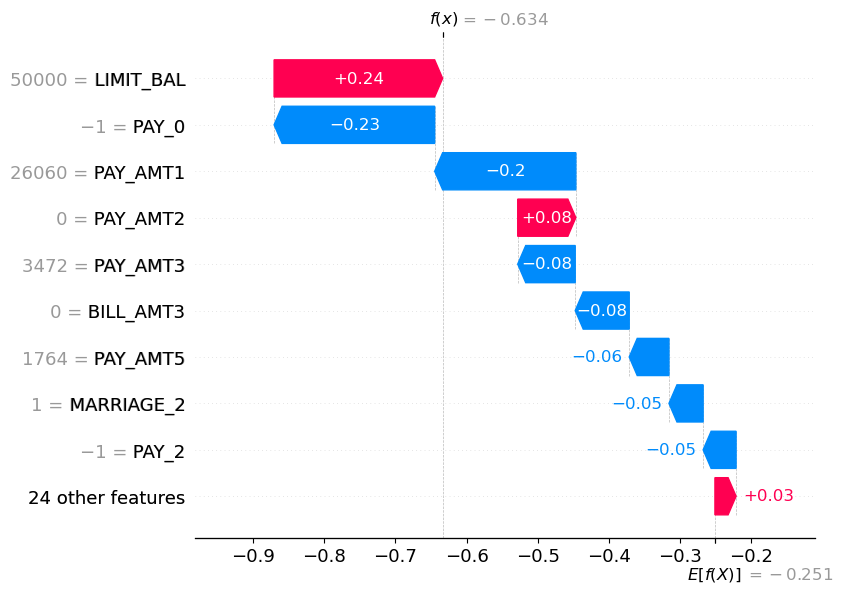

In [67]:
import shap

pre = tree_model.named_steps["preprocess"]
model = tree_model.named_steps["model"]

X_train_t = pre.transform(X_train)
X_test_t = pre.transform(X_test)

# feature names
ohe = pre.named_transformers_["cat"]
cat_names = ohe.get_feature_names_out(categorical_features)
feature_names = np.concatenate([numeric_features, cat_names])

explainer = shap.Explainer(model, X_train_t, feature_names=feature_names)
shap_values = explainer(X_test_t)

# Global explanation
shap.summary_plot(shap_values, X_test_t, feature_names=feature_names)

# Local explanation (one customer)
shap.plots.waterfall(shap_values[0])


PermutationExplainer explainer: 301it [01:22,  3.54it/s]                                                               


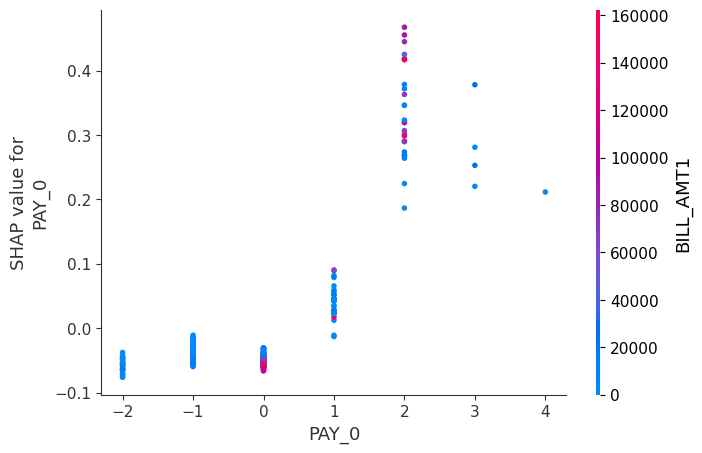

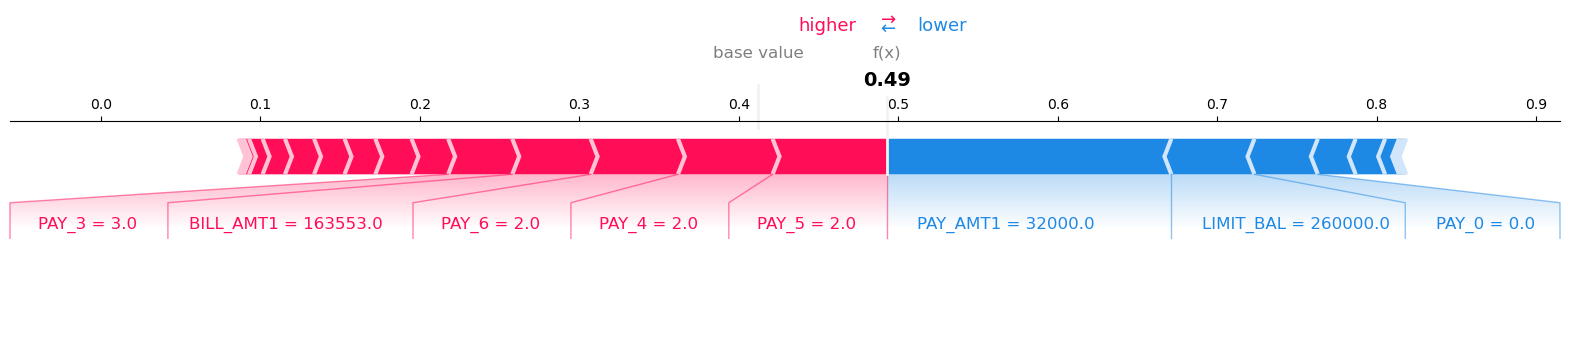

In [68]:
import shap
import numpy as np

X_bg = shap.sample(X_train, 200, random_state=42)
X_eval = X_test.sample(300, random_state=42)

# Tree_model
explainer = shap.Explainer(tree_model.predict_proba, X_bg)

shap_values = explainer(X_eval)

sv = shap_values[..., 1] 

shap.dependence_plot("PAY_0", sv.values, X_eval, feature_names=X_eval.columns)

i = 0
base_val = sv.base_values[i]
shap.plots.force(base_val, sv.values[i, :], X_eval.iloc[i, :], matplotlib=True)
